# Mini-Project 2
## Lecture 4 - Multiprocessing
### Lecture 4 - Milestone 1

Text(0, 0.5, 'Im(c)')

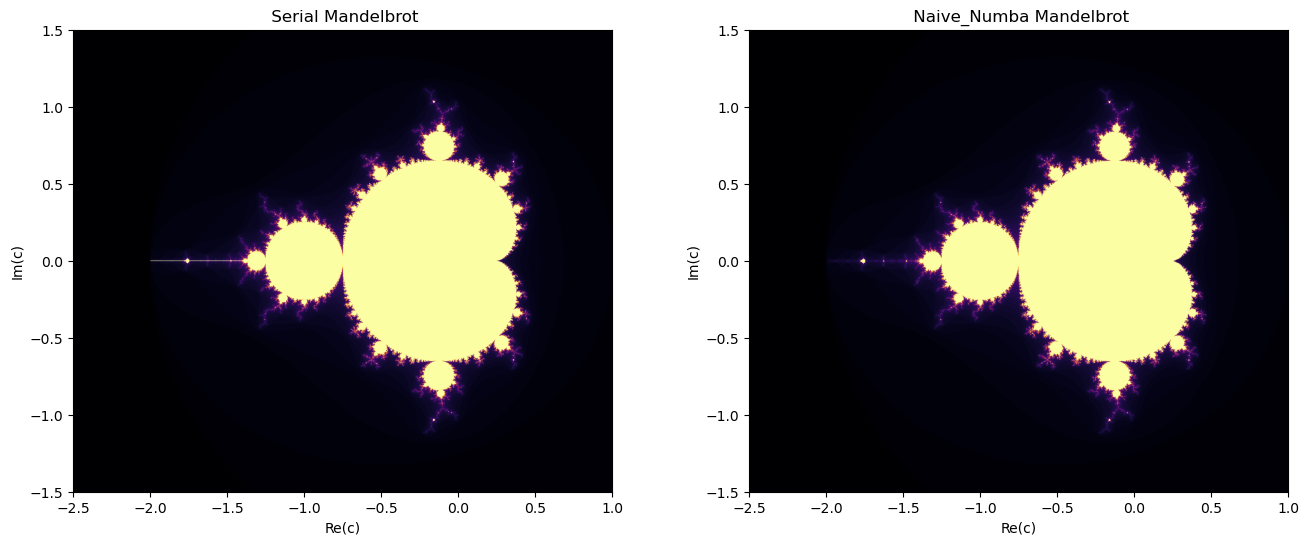

In [1]:
import numpy as np
from numba import njit
from multiprocessing import Pool
import time, os, statistics, matplotlib.pyplot as plt
from pathlib import Path
from mandelbrot_3 import benchmark, compute_mandelbrot_full
from mandelbrot_4 import mandelbrot_serial

# Parameters
iterations = 100
N = 1024
x_dim = (-2.5, 1.0)
y_dim = (-1.5, 1.5)
resolution_2 = (1024, 1024)

#Numba and serial compared
result_full = compute_mandelbrot_full(x_dim=x_dim, y_dim=y_dim, res=resolution_2, max_iter=iterations)
result_serial = mandelbrot_serial(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=iterations)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
axes[0].imshow(result_serial, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[0].set_title(' Serial Mandelbrot')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')

axes[1].imshow(result_full, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[1].set_title(' Naive_Numba Mandelbrot')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')

### Lecture 4 - Milestone 2

Text(0, 0.5, 'Im(c)')

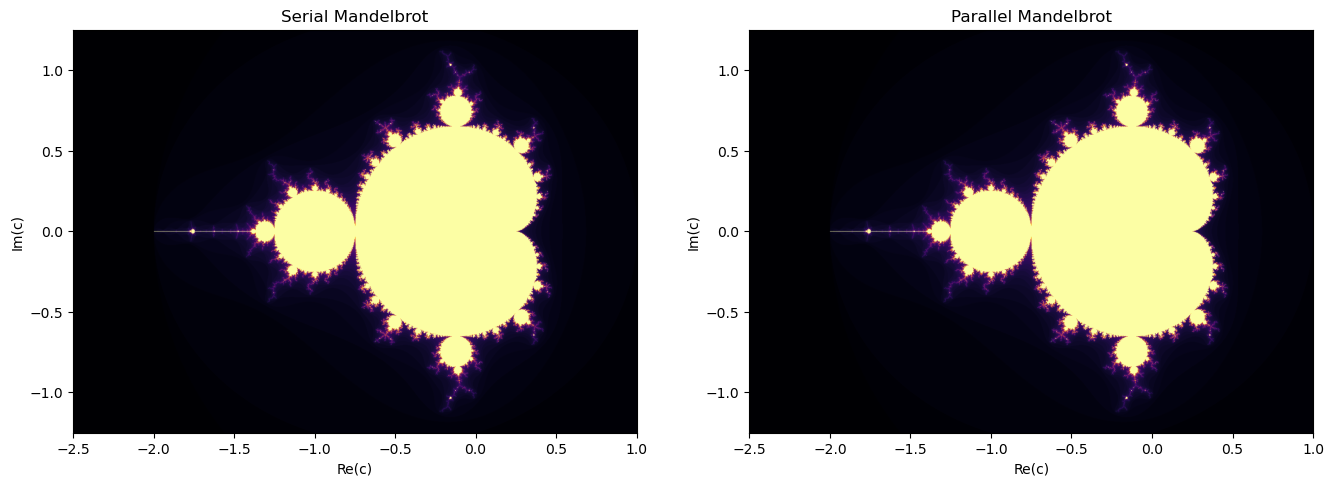

In [2]:
from mandelbrot_4 import mandelbrot_parallel, _worker    

# Parameters
N = 1024
x_dim = (-2.5, 1.0)
y_dim = (-1.25, 1.25)
num_workers = 4

# Milestone 2 testing:
result_serial = mandelbrot_serial(N=N, x_dim=x_dim, y_dim=y_dim)
result_parallel = mandelbrot_parallel(N=N, x_dim=x_dim, y_dim=y_dim, num_workers=num_workers)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
axes[0].imshow(result_serial, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[0].set_title('Serial Mandelbrot')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')

axes[1].imshow(result_parallel, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[1].set_title('Parallel Mandelbrot')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')

### Lecture 4 - Milestone 3

 1 workers | parallel time: 0.0828s | speedup: 0.86x | efficiency: 0.86
 2 workers | parallel time: 0.0473s | speedup: 1.51x | efficiency: 0.76
 3 workers | parallel time: 0.0543s | speedup: 1.32x | efficiency: 0.44
 4 workers | parallel time: 0.0418s | speedup: 1.71x | efficiency: 0.43
 5 workers | parallel time: 0.0419s | speedup: 1.71x | efficiency: 0.34
 6 workers | parallel time: 0.0373s | speedup: 1.92x | efficiency: 0.32
 7 workers | parallel time: 0.0497s | speedup: 1.44x | efficiency: 0.21
 8 workers | parallel time: 0.0315s | speedup: 2.27x | efficiency: 0.28


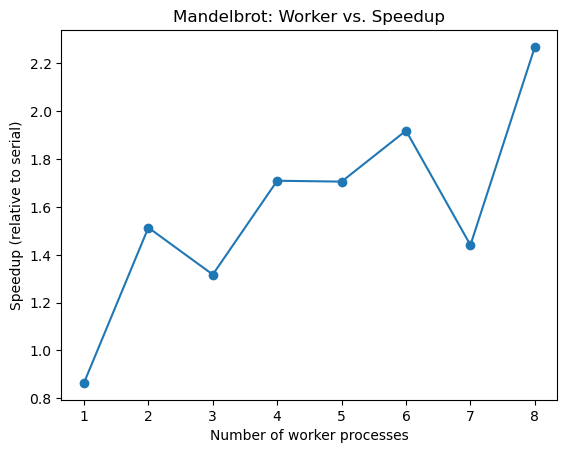

<Figure size 640x480 with 0 Axes>

In [3]:
from monte_carlo_example import plot_worker_speedup

# Parameters
N = 1024
max_iter = 100
x_dim = (-2.5, 1.0)
y_dim = (-1.25, 1.25)
num_runs = 3

workers_list = []
speedups = []

# Serial baseline (Numba already warm after M1 warm-up)
times = []
for _ in range(num_runs):
    start_time = time.perf_counter()
    mandelbrot_serial(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter)
    times.append(time.perf_counter() - start_time)
t_serial = statistics.median(times)

for num_workers in range(1, os.cpu_count() + 1):
    chunk_size = max(1, N // num_workers)
    chunks = []
    row = 0
    while row < N:
        row_end = min(row + chunk_size, N) # determine end of the row
        chunks.append((row, row_end, N, x_dim, y_dim, max_iter))
        row = row_end

    with Pool(processes=num_workers) as pool:
        pool.map(_worker, chunks)
        times = []
        for _ in range(num_runs):
            t0 = time.perf_counter()
            np.vstack(pool.map(_worker, chunks))
            times.append(time.perf_counter() - t0)
    t_parallel = statistics.median(times)
    speedup = t_serial / t_parallel

    # Append workers and speedups for plotting
    workers_list.append(num_workers)
    speedups.append(speedup)

    # print table of workers, speedup and efficiency
    print(f'{num_workers:2d} workers | '
            f'parallel time: {t_parallel:.4f}s | '
            f'speedup: {speedup:.2f}x | '
            f'efficiency: {speedup/num_workers:.2f}')

# Plot worker vs. speedup
plot_worker_speedup(title="Mandelbrot", workers=workers_list, speedup=speedups)
plt.savefig("figures/Mandelbrot_worker_speedup.png")

## Lecture 5 - Multiprocessing + Dask
### Lectue 5 - Milestone 1
Verify result matches serial output for n_chunks 

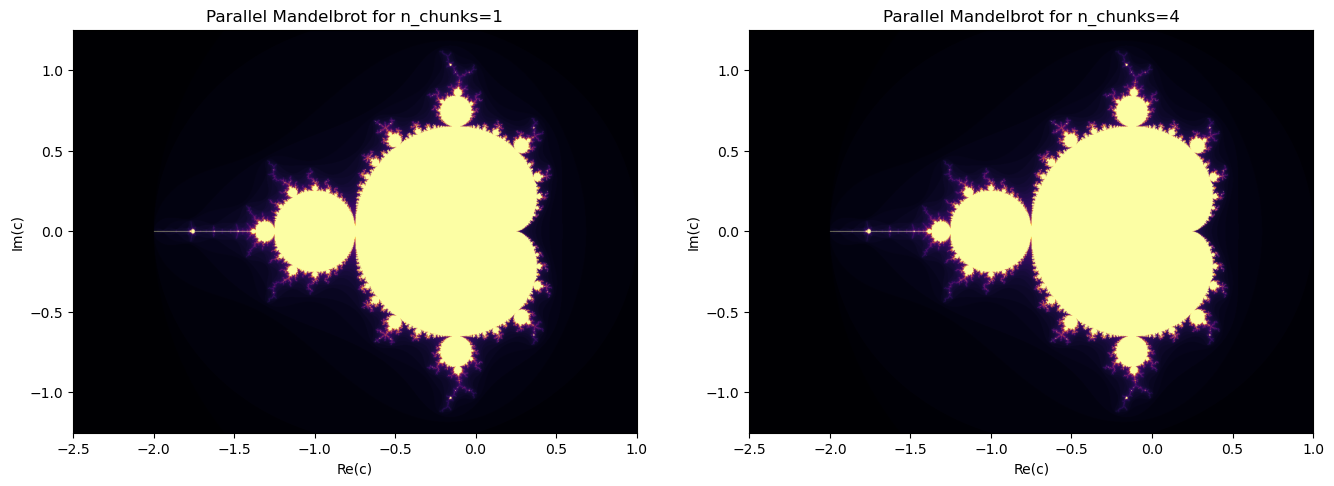

In [ ]:
from mandelbrot_5 import mandelbrot_parallel

# Milestone 1 testing:
n_chunks = 4

result_parallel_1nchunk = mandelbrot_parallel(N=N, x_dim=x_dim, y_dim=y_dim, num_workers=num_workers, n_chunks=1*num_workers)
result_parallel_4nchunks = mandelbrot_parallel(N=N, x_dim=x_dim, y_dim=y_dim, num_workers=num_workers, n_chunks=n_chunks*num_workers)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
axes[0].imshow(result_parallel_1nchunk, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[0].set_title(f'Parallel Mandelbrot for n_chunks=1 * {num_workers=}')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')

axes[1].imshow(result_parallel_4nchunks, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[1].set_title(f'Parallel Mandelbrot for {n_chunks=} * {num_workers=}')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')
plt.show()

Milestone 2